# Doprinos 5 — Analiza uticaja kvantizacije na latenciju, RAM i Real-Time Factor Faster-Whisper modela

## Cilj eksperimenta

Cilj eksperimenta je analiza uticaja kvantizacije na performanse Faster-Whisper modela pri izvršavanju na CPU-u. Direktno se porede `INT8` i `FLOAT32` konfiguracije modela `tiny`, `base`, `small` i `medium`.

Eksperiment koristi svih **40 prirodnih srpskih audio zapisa**, tako da je ukupno izvršeno **320 merenih transkripcija**. Za svaku konfiguraciju analiziraju se prosečno vreme obrade, Real-Time Factor (RTF), vreme učitavanja modela i procesna RAM memorija.

Glavni cilj je utvrditi koliko INT8 kvantizacija može ubrzati izvršavanje i smanjiti računarski zahtev u odnosu na FLOAT32, kao i kako efekat kvantizacije zavisi od veličine modela.

---

## Metodologija merenja

Za svaku kombinaciju modela i kvantizacije model se učitava jednom, nakon čega se izvršava nemereno warm-up prepoznavanje. Time se smanjuje uticaj inicijalizacije biblioteka i prvog izvršavanja na rezultate.

Svih 40 snimaka zatim se obrađuje istim parametrima dekodiranja (`beam_size=1`, `temperature=0.0`, bez VAD filtriranja). Vreme učitavanja modela ne uključuje se u vreme transkripcije.

RTF se računa kao odnos vremena obrade i trajanja audio zapisa. Vrednost `RTF < 1` znači da se audio obrađuje brže od njegovog realnog trajanja.

RAM se meri preko RSS memorije Python/Jupyter procesa. Zbog toga ove vrednosti predstavljaju praktičnu aproksimaciju memorijskog opterećenja procesa, a ne potpuno izolovanu memoriju koju zauzima samo model.


In [1]:
from pathlib import Path
import os
import gc
import time
import wave
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

from faster_whisper import WhisperModel

In [2]:
# ============================================================
# PUTANJE
# ============================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

AUDIO_DIR = PROJECT_ROOT / "audio" / "40Sentences00-08Notebooks"

REZULTATI_DIR = PROJECT_ROOT / "rezultati" / "05_kvantizacija_latencija_rtf"
REZULTATI_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("AUDIO_DIR:", AUDIO_DIR)
print("REZULTATI_DIR:", REZULTATI_DIR)

PROJECT_ROOT: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR
AUDIO_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\40Sentences00-08Notebooks
REZULTATI_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\05_kvantizacija_latencija_rtf


In [3]:
# ============================================================
# DEFINISANJE SVIH 40 PRIRODNIH SRPSKIH SNIMAKA
# ============================================================

govornik1_brojevi = set(
    list(range(1, 5)) +
    list(range(11, 16)) +
    list(range(26, 29)) +
    [36]
)

govornik2_brojevi = set(
    list(range(5, 8)) +
    list(range(16, 21)) +
    list(range(29, 32)) +
    [37, 38]
)

govornik3_brojevi = set(
    list(range(8, 11)) +
    list(range(21, 26)) +
    list(range(32, 36)) +
    [39, 40]
)


def odredi_govornika(broj):
    if broj in govornik1_brojevi:
        return "govornik1"
    if broj in govornik2_brojevi:
        return "govornik2"
    if broj in govornik3_brojevi:
        return "govornik3"
    raise ValueError(f"Nepoznat govornik za audio broj {broj}")


def odredi_grupu_duzine(broj):
    if 1 <= broj <= 10:
        return "kratki"
    elif 11 <= broj <= 25:
        return "srednji"
    elif 26 <= broj <= 35:
        return "dugi"
    elif 36 <= broj <= 40:
        return "veoma_dugi"
    else:
        raise ValueError(f"Nepoznata grupa za audio broj {broj}")


test_set = []

for broj in range(1, 41):
    govornik = odredi_govornika(broj)
    grupa = odredi_grupu_duzine(broj)

    fajl = AUDIO_DIR / f"{broj}{govornik}.wav"

    test_set.append({
        "broj": broj,
        "audio": fajl,
        "govornik": govornik,
        "grupa": grupa
    })


for item in test_set:
    if not item["audio"].exists():
        raise FileNotFoundError(
            f"Audio fajl nije pronađen: {item['audio']}"
        )

print(f"Sva {len(test_set)} audio fajla su pronađena.")

print("\nBroj fajlova po govorniku:")
print(pd.Series([x["govornik"] for x in test_set]).value_counts())

print("\nBroj fajlova po grupi dužine:")
print(pd.Series([x["grupa"] for x in test_set]).value_counts())

Sva 40 audio fajla su pronađena.

Broj fajlova po govorniku:
govornik3    14
govornik1    13
govornik2    13
Name: count, dtype: int64

Broj fajlova po grupi dužine:
srednji       15
kratki        10
dugi          10
veoma_dugi     5
Name: count, dtype: int64


In [4]:
# ============================================================
# POMOĆNE FUNKCIJE
# ============================================================

def trajanje_wav(putanja):
    with wave.open(str(putanja), "rb") as wf:
        frames = wf.getnframes()
        rate = wf.getframerate()
        return frames / float(rate)


process = psutil.Process(os.getpid())


def trenutni_ram_mb():
    return process.memory_info().rss / (1024 ** 2)


def transkribuj_i_izmeri(model, putanja):
    """
    Meri ukupno vreme obrade i procesni peak RSS tokom transkripcije.

    RAM delta predstavlja povećanje procesnog RSS-a iznad vrednosti
    neposredno pre početka transkripcije.
    """

    ram_pre = trenutni_ram_mb()

    memorija_uzorci = [ram_pre]
    stop_event = threading.Event()

    def monitor_memorije():
        while not stop_event.is_set():
            memorija_uzorci.append(trenutni_ram_mb())
            time.sleep(0.02)

        memorija_uzorci.append(trenutni_ram_mb())

    monitor_thread = threading.Thread(
        target=monitor_memorije,
        daemon=True
    )

    monitor_thread.start()

    start = time.perf_counter()

    try:
        segments, info = model.transcribe(
            str(putanja),
            language="sr",
            beam_size=1,
            temperature=0.0,
            vad_filter=False
        )

        transkript = " ".join(
            segment.text.strip()
            for segment in segments
        ).strip()

    finally:
        vreme = time.perf_counter() - start

        stop_event.set()
        monitor_thread.join()

    peak_ram = max(memorija_uzorci)
    dodatni_ram = max(0.0, peak_ram - ram_pre)

    return {
        "transkript": transkript,
        "vreme": vreme,
        "ram_pre": ram_pre,
        "peak_ram": peak_ram,
        "dodatni_ram": dodatni_ram
    }

In [5]:
# ============================================================
# KONFIGURACIJE EKSPERIMENTA
# ============================================================

model_velicine = [
    "tiny",
    "base",
    "small",
    "medium"
]

kvantizacije = [
    "int8",
    "float32"
]

uredjaj = "cpu"

print("Modeli:", model_velicine)
print("Kvantizacije:", kvantizacije)
print("Uređaj:", uredjaj)
print(
    "Ukupan broj merenih transkripcija:",
    len(model_velicine) * len(kvantizacije) * len(test_set)
)

Modeli: ['tiny', 'base', 'small', 'medium']
Kvantizacije: ['int8', 'float32']
Uređaj: cpu
Ukupan broj merenih transkripcija: 320


In [6]:
# ============================================================
# GLAVNI EKSPERIMENT
# ============================================================

rezultati = []
model_load_rezultati = []


for model_size in model_velicine:

    for compute_type in kvantizacije:

        print("\n" + "=" * 100)
        print(
            f"MODEL = {model_size.upper()} | "
            f"KVANTIZACIJA = {compute_type.upper()} | CPU"
        )
        print("=" * 100)


        gc.collect()
        time.sleep(0.5)

        ram_pre_ucitavanja = trenutni_ram_mb()

        start_load = time.perf_counter()

        try:
            model = WhisperModel(
                model_size,
                device="cpu",
                compute_type=compute_type
            )

        except Exception as e:
            print(
                f"Greška pri učitavanju {model_size} / "
                f"{compute_type}: {e}"
            )
            continue


        load_time = time.perf_counter() - start_load

        ram_nakon_ucitavanja = trenutni_ram_mb()
        ram_delta_model = max(
            0.0,
            ram_nakon_ucitavanja - ram_pre_ucitavanja
        )


        print(f"Vreme učitavanja modela: {load_time:.2f} s")
        print(f"RSS pre učitavanja: {ram_pre_ucitavanja:.2f} MB")
        print(f"RSS nakon učitavanja: {ram_nakon_ucitavanja:.2f} MB")
        print(f"Promena RSS-a pri učitavanju: {ram_delta_model:.2f} MB")


        model_load_rezultati.append({
            "Model": model_size,
            "Kvantizacija": compute_type,
            "Uređaj": "cpu",
            "Model Load Time [s]": round(load_time, 3),
            "RSS pre učitavanja [MB]": round(ram_pre_ucitavanja, 2),
            "RSS nakon učitavanja [MB]": round(ram_nakon_ucitavanja, 2),
            "RAM delta učitavanja [MB]": round(ram_delta_model, 2)
        })


        # --------------------------------------------------------
        # WARM-UP — NE ULAZI U REZULTATE
        # --------------------------------------------------------

        print("Warm-up...")

        try:
            segments, _ = model.transcribe(
                str(test_set[0]["audio"]),
                language="sr",
                beam_size=1,
                temperature=0.0,
                vad_filter=False
            )

            _ = " ".join(
                segment.text.strip()
                for segment in segments
            )

        except Exception as e:
            print("Warm-up greška:", e)


        print("Počinje merenje 40 audio zapisa...\n")


        for indeks, item in enumerate(test_set, start=1):

            audio_trajanje = trajanje_wav(item["audio"])

            try:
                merenje = transkribuj_i_izmeri(
                    model,
                    item["audio"]
                )

            except Exception as e:
                print(
                    f"GREŠKA {item['audio'].name}: {e}"
                )
                continue


            latency = merenje["vreme"]

            rtf = (
                latency / audio_trajanje
                if audio_trajanje > 0
                else np.nan
            )


            rezultati.append({
                "Model": model_size,
                "Kvantizacija": compute_type,
                "Uređaj": "cpu",
                "Broj": item["broj"],
                "Audio": item["audio"].name,
                "Govornik": item["govornik"],
                "Grupa_duzine": item["grupa"],
                "Audio Trajanje [s]": round(audio_trajanje, 3),
                "Vreme obrade [s]": round(latency, 3),
                "RTF": round(rtf, 4),
                "Brže od realnog vremena": bool(rtf < 1.0),
                "RSS pre transkripcije [MB]": round(merenje["ram_pre"], 2),
                "Peak RSS [MB]": round(merenje["peak_ram"], 2),
                "Dodatni peak RAM [MB]": round(merenje["dodatni_ram"], 2),
                "Model Load Time [s]": round(load_time, 3),
                "Transkript": merenje["transkript"]
            })


            print(
                f"[{indeks:02d}/40] "
                f"{item['audio'].name:<20} | "
                f"{audio_trajanje:7.2f} s audio | "
                f"{latency:7.2f} s obrada | "
                f"RTF {rtf:6.3f} | "
                f"RAM +{merenje['dodatni_ram']:7.2f} MB"
            )


        del model
        gc.collect()
        time.sleep(1.0)


print("\nEksperiment je završen.")
print(f"Broj uspešnih merenja: {len(rezultati)}")


MODEL = TINY | KVANTIZACIJA = INT8 | CPU
Vreme učitavanja modela: 0.79 s
RSS pre učitavanja: 286.53 MB
RSS nakon učitavanja: 322.66 MB
Promena RSS-a pri učitavanju: 36.12 MB
Warm-up...
Počinje merenje 40 audio zapisa...

[01/40] 1govornik1.wav       |    7.60 s audio |    0.77 s obrada | RTF  0.101 | RAM + 117.26 MB
[02/40] 2govornik1.wav       |    6.78 s audio |    0.71 s obrada | RTF  0.105 | RAM + 116.70 MB
[03/40] 3govornik1.wav       |    5.83 s audio |    0.75 s obrada | RTF  0.128 | RAM + 116.82 MB
[04/40] 4govornik1.wav       |    7.29 s audio |    0.68 s obrada | RTF  0.094 | RAM + 116.44 MB
[05/40] 5govornik2.wav       |    9.33 s audio |    0.84 s obrada | RTF  0.090 | RAM + 116.39 MB
[06/40] 6govornik2.wav       |    7.89 s audio |    0.70 s obrada | RTF  0.089 | RAM + 116.22 MB
[07/40] 7govornik2.wav       |    8.73 s audio |    0.70 s obrada | RTF  0.080 | RAM + 116.21 MB
[08/40] 8govornik3.wav       |    5.21 s audio |    0.60 s obrada | RTF  0.116 | RAM + 116.23 MB
[0

In [7]:
# ============================================================
# DETALJNI REZULTATI
# ============================================================

tabela_rezultati = pd.DataFrame(rezultati)
tabela_model_load = pd.DataFrame(model_load_rezultati)

display(
    tabela_rezultati[
        [
            "Model",
            "Kvantizacija",
            "Broj",
            "Audio",
            "Govornik",
            "Grupa_duzine",
            "Audio Trajanje [s]",
            "Vreme obrade [s]",
            "RTF",
            "Dodatni peak RAM [MB]"
        ]
    ]
)

,Model,Kvantizacija,Broj,Audio,Govornik,Grupa_duzine,Audio Trajanje [s],Vreme obrade [s],RTF,Dodatni peak RAM [MB]
0,tiny,int8,1,1govornik1.wav,govornik1,kratki,7.605,0.768,0.1010,117.26
1,tiny,int8,2,2govornik1.wav,govornik1,kratki,6.780,0.709,0.1046,116.70
2,tiny,int8,3,3govornik1.wav,govornik1,kratki,5.828,0.745,0.1279,116.82
3,tiny,int8,4,4govornik1.wav,govornik1,kratki,7.291,0.682,0.0936,116.44
4,tiny,int8,5,5govornik2.wav,govornik2,kratki,9.334,0.838,0.0898,116.39
...,...,...,...,...,...,...,...,...,...,...
315,medium,float32,36,36govornik1.wav,govornik1,veoma_dugi,69.010,95.664,1.3862,360.66
316,medium,float32,37,37govornik2.wav,govornik2,veoma_dugi,82.431,90.787,1.1014,692.85
317,medium,float32,38,38govornik2.wav,govornik2,veoma_dugi,64.459,60.898,0.9448,486.68
318,medium,float32,39,39govornik3.wav,govornik3,veoma_dugi,62.613,78.411,1.2523,397.39


In [8]:
# ============================================================
# PROSEČNE VREDNOSTI PO KONFIGURACIJI
# ============================================================

tabela_prosek = (
    tabela_rezultati
    .groupby([
        "Model",
        "Kvantizacija",
        "Uređaj"
    ])
    .agg(
        Broj_snimaka=("Audio", "count"),
        Prosecno_trajanje=("Audio Trajanje [s]", "mean"),
        Prosecno_vreme=("Vreme obrade [s]", "mean"),
        Medijana_vremena=("Vreme obrade [s]", "median"),
        Ukupno_vreme=("Vreme obrade [s]", "sum"),
        Prosecan_RTF=("RTF", "mean"),
        Medijana_RTF=("RTF", "median"),
        Peak_RTF=("RTF", "max"),
        Prosecan_dodatni_RAM=("Dodatni peak RAM [MB]", "mean"),
        Medijana_dodatni_RAM=("Dodatni peak RAM [MB]", "median"),
        Maksimalni_dodatni_RAM=("Dodatni peak RAM [MB]", "max"),
        Udeo_RTF_ispod_1=("Brže od realnog vremena", "mean")
    )
    .reset_index()
)


tabela_prosek["Udeo RTF < 1 [%]"] = (
    tabela_prosek["Udeo_RTF_ispod_1"] * 100
)

tabela_prosek = tabela_prosek.drop(
    columns=["Udeo_RTF_ispod_1"]
)

tabela_prosek = tabela_prosek.round(3)

print("PROSEČNI REZULTATI PO KONFIGURACIJI")
display(tabela_prosek)

PROSEČNI REZULTATI PO KONFIGURACIJI


,Model,Kvantizacija,Uređaj,Broj_snimaka,Prosecno_trajanje,Prosecno_vreme,Medijana_vremena,Ukupno_vreme,Prosecan_RTF,Medijana_RTF,Peak_RTF,Prosecan_dodatni_RAM,Medijana_dodatni_RAM,Maksimalni_dodatni_RAM,Udeo RTF < 1 [%]
0,base,float32,cpu,40,24.411,3.002,2.120,120.090,0.148,0.131,0.283,156.329,155.430,181.29,100.0
1,base,int8,cpu,40,24.411,2.161,1.447,86.449,0.110,0.094,0.299,154.690,155.045,216.69,100.0
2,medium,float32,cpu,40,24.411,28.991,19.796,1159.645,1.390,1.209,3.025,416.830,342.515,1068.91,25.0
3,medium,int8,cpu,40,24.411,17.633,11.272,705.325,0.832,0.753,1.527,349.956,319.415,821.02,80.0
4,small,float32,cpu,40,24.411,8.734,6.143,349.372,0.428,0.386,0.793,254.700,236.585,501.40,100.0
5,small,int8,cpu,40,24.411,7.203,4.434,288.127,0.327,0.297,0.562,249.288,233.650,408.55,100.0
6,tiny,float32,cpu,40,24.411,1.656,1.158,66.252,0.081,0.074,0.146,116.784,116.255,120.85,100.0
7,tiny,int8,cpu,40,24.411,1.355,0.956,54.188,0.069,0.061,0.128,116.954,116.245,121.37,100.0


## Analiza ukupnih rezultata

Rezultati pokazuju da povećanje veličine modela značajno povećava vreme obrade i RTF, dok INT8 kvantizacija u svim testiranim veličinama modela smanjuje prosečno vreme izvršavanja u odnosu na FLOAT32.

Najbrža konfiguracija je **tiny INT8**, sa prosečnim vremenom od **1,355 s** i prosečnim RTF-om od **0,069**. Za `base INT8` dobijeno je **2,161 s** i RTF **0,110**, dok `small INT8` zahteva **7,203 s** uz RTF **0,327**.

Najveća razlika između INT8 i FLOAT32 uočena je kod `medium` modela. Prosečno vreme smanjeno je sa **28,991 s** za FLOAT32 na **17,633 s** za INT8, dok je prosečan RTF smanjen sa **1,390** na **0,832**.

Ova razlika je posebno značajna sa stanovišta obrade u realnom vremenu. `medium FLOAT32` imao je RTF manji od 1 na samo **25% snimaka**, dok je kod `medium INT8` taj uslov ispunjen na **80% snimaka**. Nasuprot tome, sve `tiny`, `base` i `small` konfiguracije imale su RTF manji od 1 na svih 40 snimaka.

### Direktan efekat INT8 kvantizacije

U odnosu na FLOAT32, INT8 je ostvario sledeća ubrzanja:

* `tiny`: **1,22×**, odnosno **18,18%** manje prosečno vreme;
* `base`: **1,39×**, odnosno **28,02%** manje vreme;
* `small`: **1,21×**, odnosno **17,53%** manje vreme;
* `medium`: **1,64×**, odnosno **39,18%** manje vreme.

Rezultati pokazuju da korist od INT8 kvantizacije nije jednaka za sve veličine modela. Najizraženiji efekat u ovom eksperimentu ostvaren je kod `medium` modela, gde INT8 značajno smanjuje i vreme obrade i RTF.

### Analiza RAM memorije

Kod dodatnog peak RAM-a tokom same transkripcije razlike između INT8 i FLOAT32 nisu jednako izražene kao kod vremena izvršavanja. Prosečni dodatni RAM iznosi približno **117 MB** za obe `tiny` konfiguracije, oko **155–156 MB** za `base`, **249 MB naspram 255 MB** za `small`, dok je kod `medium` modela razlika izraženija: približno **350 MB za INT8** i **417 MB za FLOAT32**.

Kod `medium` modela to predstavlja približno **16% manje dodatnog peak RAM-a** za INT8. Međutim, zbog načina merenja RSS-a Python/Jupyter procesa, RAM rezultate treba interpretirati opreznije od rezultata vremena i RTF-a. Posebno, male razlike kod `tiny`, `base` i `small` modela ne treba predstavljati kao dokaz velikog smanjenja memornje različitih dužina audio zapisa.


In [9]:
# ============================================================
# MODEL LOAD TIME I RAM PRI UČITAVANJU
# ============================================================

display(tabela_model_load)

,Model,Kvantizacija,Uređaj,Model Load Time [s],RSS pre učitavanja [MB],RSS nakon učitavanja [MB],RAM delta učitavanja [MB]
0,tiny,int8,cpu,0.789,286.53,322.66,36.12
1,tiny,float32,cpu,0.356,273.83,430.27,156.43
2,base,int8,cpu,0.582,272.35,363.39,91.04
3,base,float32,cpu,0.571,196.02,492.97,296.95
4,small,int8,cpu,1.181,172.38,436.18,263.80
5,small,float32,cpu,1.119,176.51,1119.12,942.61
6,medium,int8,cpu,3.577,176.91,847.88,670.97
7,medium,float32,cpu,6.031,170.39,705.81,535.43


In [10]:
# ============================================================
# REZULTATI PO DUŽINI AUDIO ZAPISA
# ============================================================

rezime_duzine = (
    tabela_rezultati
    .groupby([
        "Model",
        "Kvantizacija",
        "Grupa_duzine"
    ])
    .agg(
        Broj_snimaka=("Audio", "count"),
        Prosecno_trajanje=("Audio Trajanje [s]", "mean"),
        Prosecno_vreme=("Vreme obrade [s]", "mean"),
        Prosecan_RTF=("RTF", "mean"),
        Prosecan_dodatni_RAM=("Dodatni peak RAM [MB]", "mean")
    )
    .reset_index()
    .round(3)
)

print("REZULTATI PO DUŽINI AUDIO SNIMKA")
display(rezime_duzine)

REZULTATI PO DUŽINI AUDIO SNIMKA


,Model,Kvantizacija,Grupa_duzine,Broj_snimaka,Prosecno_trajanje,Prosecno_vreme,Prosecan_RTF,Prosecan_dodatni_RAM
0,base,float32,dugi,10,31.831,3.647,0.115,156.972
1,base,float32,kratki,10,6.961,1.414,0.212,155.169
2,base,float32,srednji,15,15.348,2.124,0.141,155.215
3,base,float32,veoma_dugi,5,71.657,7.526,0.106,160.702
4,base,int8,dugi,10,31.831,2.550,0.080,153.223
5,base,int8,kratki,10,6.961,1.229,0.183,156.188
6,base,int8,srednji,15,15.348,1.402,0.093,152.625
7,base,int8,veoma_dugi,5,71.657,5.526,0.078,160.818
8,medium,float32,dugi,10,31.831,33.328,1.047,368.455
9,medium,float32,kratki,10,6.961,13.954,2.090,353.605


### Uticaj dužine audio zapisa

RTF je generalno veći kod kratkih nego kod dužih snimaka, jer fiksni troškovi pokretanja obrade imaju proporcionalno veći uticaj na kratke audio zapise.

Na primer, kod `tiny INT8` prosečan RTF opada sa **0,104** za kratke na **0,043** za veoma duge snimke. Kod `base INT8` opada sa **0,183** na **0,078**, dok kod `small INT8` opada sa **0,444** na **0,277**.

Kod `medium` modela INT8 takođe pokazuje znatno niže RTF vrednosti od FLOAT32 kroz grupe dužine. Za veoma duge snimke prosečan RTF iznosi **0,651** za INT8 naspram **1,142** za FLOAT32.

Ovi rezultati pokazuju da trajanje snimka utiče na relativnu efikasnost obrade i da samo apsolutno vreme izvršavanja nije dovoljno za poređenje različitih dužina audio zapisa.

In [11]:
# ============================================================
# REZULTATI PO GOVORNIKU
# ============================================================

rezime_govornici = (
    tabela_rezultati
    .groupby([
        "Model",
        "Kvantizacija",
        "Govornik"
    ])
    .agg(
        Broj_snimaka=("Audio", "count"),
        Prosecno_vreme=("Vreme obrade [s]", "mean"),
        Prosecan_RTF=("RTF", "mean"),
        Prosecan_dodatni_RAM=("Dodatni peak RAM [MB]", "mean")
    )
    .reset_index()
    .round(3)
)

print("REZULTATI PO GOVORNIKU")
display(rezime_govornici)

REZULTATI PO GOVORNIKU


,Model,Kvantizacija,Govornik,Broj_snimaka,Prosecno_vreme,Prosecan_RTF,Prosecan_dodatni_RAM
0,base,float32,govornik1,13,2.911,0.168,157.099
1,base,float32,govornik2,13,3.062,0.118,157.059
2,base,float32,govornik3,14,3.032,0.156,154.935
3,base,int8,govornik1,13,1.974,0.123,159.271
4,base,int8,govornik2,13,2.274,0.091,156.199
5,base,int8,govornik3,14,2.230,0.116,149.034
6,medium,float32,govornik1,13,28.259,1.588,451.012
7,medium,float32,govornik2,13,28.602,1.089,425.198
8,medium,float32,govornik3,14,30.032,1.487,377.318
9,medium,int8,govornik1,13,16.078,0.867,324.955


In [12]:
# ============================================================
# DIREKTNO POREĐENJE INT8 VS FLOAT32
# ============================================================

poredjenje_redovi = []


for model_size in model_velicine:

    podaci_model = tabela_prosek[
        tabela_prosek["Model"] == model_size
    ]

    int8_red = podaci_model[
        podaci_model["Kvantizacija"] == "int8"
    ]

    f32_red = podaci_model[
        podaci_model["Kvantizacija"] == "float32"
    ]


    if len(int8_red) == 0 or len(f32_red) == 0:
        continue

    int8_red = int8_red.iloc[0]
    f32_red = f32_red.iloc[0]


    vreme_int8 = int8_red["Prosecno_vreme"]
    vreme_f32 = f32_red["Prosecno_vreme"]

    rtf_int8 = int8_red["Prosecan_RTF"]
    rtf_f32 = f32_red["Prosecan_RTF"]

    ram_int8 = int8_red["Prosecan_dodatni_RAM"]
    ram_f32 = f32_red["Prosecan_dodatni_RAM"]


    speedup = (
        vreme_f32 / vreme_int8
        if vreme_int8 > 0
        else np.nan
    )

    smanjenje_vremena = (
        (vreme_f32 - vreme_int8) / vreme_f32 * 100
        if vreme_f32 > 0
        else np.nan
    )

    smanjenje_rtf = (
        (rtf_f32 - rtf_int8) / rtf_f32 * 100
        if rtf_f32 > 0
        else np.nan
    )

    smanjenje_ram = (
        (ram_f32 - ram_int8) / ram_f32 * 100
        if ram_f32 > 0
        else np.nan
    )


    poredjenje_redovi.append({
        "Model": model_size,
        "INT8 vreme [s]": vreme_int8,
        "FLOAT32 vreme [s]": vreme_f32,
        "Speedup INT8 [x]": speedup,
        "Smanjenje vremena INT8 [%]": smanjenje_vremena,
        "INT8 RTF": rtf_int8,
        "FLOAT32 RTF": rtf_f32,
        "Smanjenje RTF INT8 [%]": smanjenje_rtf,
        "INT8 dodatni RAM [MB]": ram_int8,
        "FLOAT32 dodatni RAM [MB]": ram_f32,
        "Smanjenje dodatnog RAM INT8 [%]": smanjenje_ram
    })


tabela_poredjenje = pd.DataFrame(poredjenje_redovi).round(3)

print("INT8 VS FLOAT32")
display(tabela_poredjenje)

INT8 VS FLOAT32


,Model,INT8 vreme [s],FLOAT32 vreme [s],Speedup INT8 [x],Smanjenje vremena INT8 [%],INT8 RTF,FLOAT32 RTF,Smanjenje RTF INT8 [%],INT8 dodatni RAM [MB],FLOAT32 dodatni RAM [MB],Smanjenje dodatnog RAM INT8 [%]
0,tiny,1.355,1.656,1.222,18.176,0.069,0.081,14.815,116.954,116.784,-0.146
1,base,2.161,3.002,1.389,28.015,0.110,0.148,25.676,154.690,156.329,1.048
2,small,7.203,8.734,1.213,17.529,0.327,0.428,23.598,249.288,254.700,2.125
3,medium,17.633,28.991,1.644,39.178,0.832,1.390,40.144,349.956,416.830,16.043


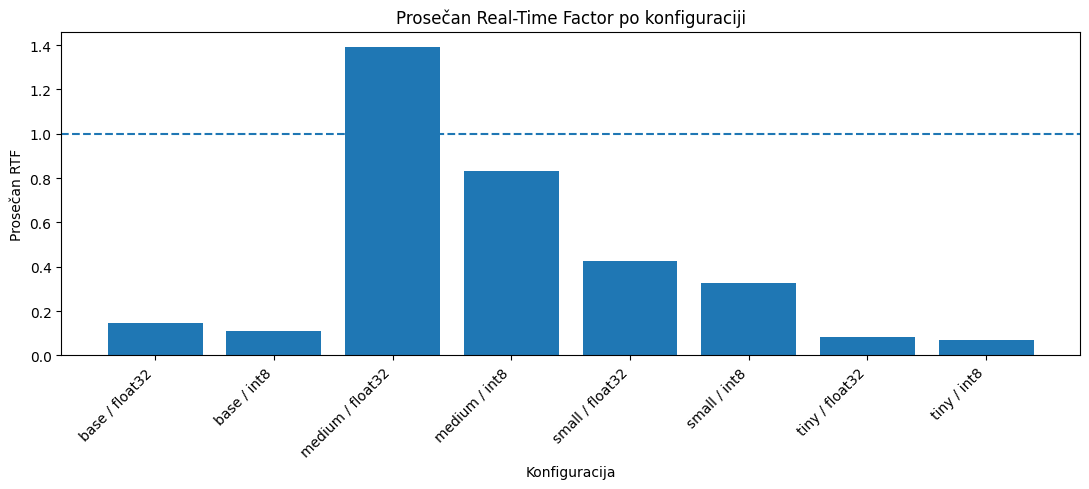

In [13]:
# ============================================================
# GRAFIK — PROSEČAN RTF
# ============================================================

grafik_rtf = tabela_prosek.copy()

grafik_rtf["Konfiguracija"] = (
    grafik_rtf["Model"] +
    " / " +
    grafik_rtf["Kvantizacija"]
)

plt.figure(figsize=(11, 5))

plt.bar(
    grafik_rtf["Konfiguracija"],
    grafik_rtf["Prosecan_RTF"]
)

plt.axhline(
    1.0,
    linestyle="--"
)

plt.xlabel("Konfiguracija")
plt.ylabel("Prosečan RTF")
plt.title("Prosečan Real-Time Factor po konfiguraciji")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

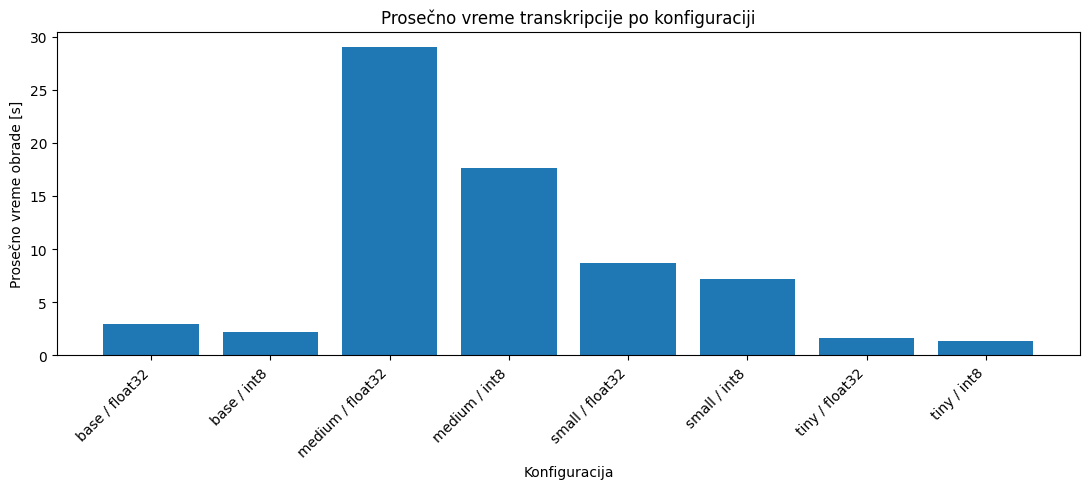

In [14]:
# ============================================================
# GRAFIK — PROSEČNO VREME OBRADE
# ============================================================

plt.figure(figsize=(11, 5))

plt.bar(
    grafik_rtf["Konfiguracija"],
    grafik_rtf["Prosecno_vreme"]
)

plt.xlabel("Konfiguracija")
plt.ylabel("Prosečno vreme obrade [s]")
plt.title("Prosečno vreme transkripcije po konfiguraciji")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

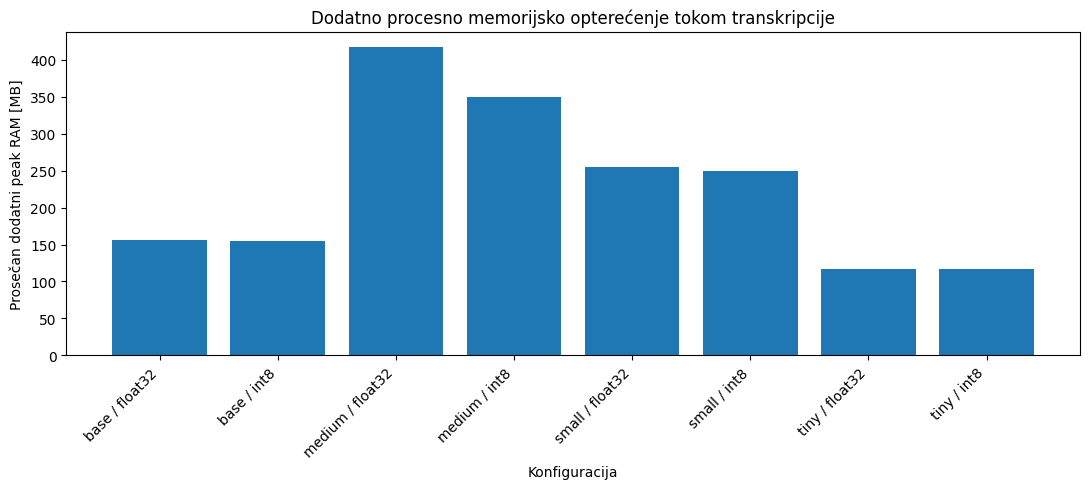

In [15]:
# ============================================================
# GRAFIK — DODATNI PEAK RAM
# ============================================================

plt.figure(figsize=(11, 5))

plt.bar(
    grafik_rtf["Konfiguracija"],
    grafik_rtf["Prosecan_dodatni_RAM"]
)

plt.xlabel("Konfiguracija")
plt.ylabel("Prosečan dodatni peak RAM [MB]")
plt.title("Dodatno procesno memorijsko opterećenje tokom transkripcije")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

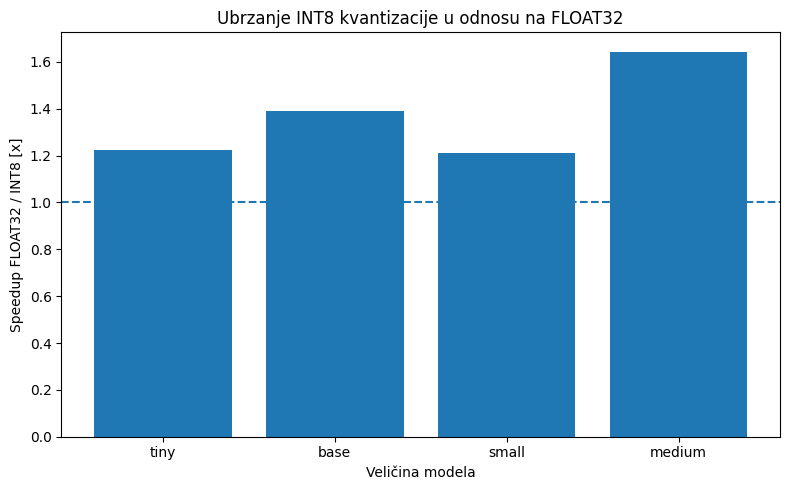

In [16]:
# ============================================================
# GRAFIK — INT8 SPEEDUP U ODNOSU NA FLOAT32
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    tabela_poredjenje["Model"],
    tabela_poredjenje["Speedup INT8 [x]"]
)

plt.axhline(
    1.0,
    linestyle="--"
)

plt.xlabel("Veličina modela")
plt.ylabel("Speedup FLOAT32 / INT8 [x]")
plt.title("Ubrzanje INT8 kvantizacije u odnosu na FLOAT32")
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# AUTOMATSKI ZAVRŠNI REZIME
# ============================================================

najbrza = tabela_prosek.loc[
    tabela_prosek["Prosecno_vreme"].idxmin()
]

najmanji_rtf = tabela_prosek.loc[
    tabela_prosek["Prosecan_RTF"].idxmin()
]


print("=" * 100)
print("ZAVRŠNI REZIME — KVANTIZACIJA, LATENCIJA I RTF")
print("=" * 100)

print(f"Broj audio zapisa: {len(test_set)}")
print(f"Broj modela: {len(model_velicine)}")
print(f"Broj kvantizacija: {len(kvantizacije)}")
print(f"Broj uspešnih merenja: {len(tabela_rezultati)}")

print(
    f"\nNajbrža konfiguracija: "
    f"{najbrza['Model']} / {najbrza['Kvantizacija']}"
)
print(
    f"Prosečno vreme: {najbrza['Prosecno_vreme']:.3f} s"
)

print(
    f"Najmanji prosečan RTF: "
    f"{najmanji_rtf['Model']} / {najmanji_rtf['Kvantizacija']} "
    f"= {najmanji_rtf['Prosecan_RTF']:.4f}"
)


print("\nINT8 VS FLOAT32:")

for _, red in tabela_poredjenje.iterrows():
    print(
        f"{red['Model']:<7} | "
        f"speedup {red['Speedup INT8 [x]']:.2f}x | "
        f"smanjenje vremena {red['Smanjenje vremena INT8 [%]']:.2f}% | "
        f"RTF INT8 {red['INT8 RTF']:.3f} | "
        f"RTF F32 {red['FLOAT32 RTF']:.3f}"
    )

ZAVRŠNI REZIME — KVANTIZACIJA, LATENCIJA I RTF
Broj audio zapisa: 40
Broj modela: 4
Broj kvantizacija: 2
Broj uspešnih merenja: 320

Najbrža konfiguracija: tiny / int8
Prosečno vreme: 1.355 s
Najmanji prosečan RTF: tiny / int8 = 0.0690

INT8 VS FLOAT32:
tiny    | speedup 1.22x | smanjenje vremena 18.18% | RTF INT8 0.069 | RTF F32 0.081
base    | speedup 1.39x | smanjenje vremena 28.02% | RTF INT8 0.110 | RTF F32 0.148
small   | speedup 1.21x | smanjenje vremena 17.53% | RTF INT8 0.327 | RTF F32 0.428
medium  | speedup 1.64x | smanjenje vremena 39.18% | RTF INT8 0.832 | RTF F32 1.390


In [18]:
# ============================================================
# ČUVANJE REZULTATA
# ============================================================

tabela_rezultati.to_csv(
    REZULTATI_DIR / "05_svi_rezultati.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_prosek.to_csv(
    REZULTATI_DIR / "05_rezime_konfiguracije.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_model_load.to_csv(
    REZULTATI_DIR / "05_model_load_ram.csv",
    index=False,
    encoding="utf-8-sig"
)

rezime_duzine.to_csv(
    REZULTATI_DIR / "05_po_duzini.csv",
    index=False,
    encoding="utf-8-sig"
)

rezime_govornici.to_csv(
    REZULTATI_DIR / "05_po_govorniku.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_poredjenje.to_csv(
    REZULTATI_DIR / "05_int8_vs_float32.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Rezultati su sačuvani u:")
print(REZULTATI_DIR)

Rezultati su sačuvani u:
D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\05_kvantizacija_latencija_rtf


## Zaključak eksperimenta

Eksperiment na 40 prirodnih srpskih audio zapisa pokazao je da INT8 kvantizacija može značajno poboljšati performanse Faster-Whisper modela pri CPU izvršavanju.

INT8 je bio brži od FLOAT32 za sve četiri testirane veličine modela. Ostvareno ubrzanje iznosilo je **1,22× za tiny**, **1,39× za base**, **1,21× za small** i **1,64× za medium**. Najveći efekat kvantizacije zato je zabeležen kod `medium` modela, gde je prosečno vreme smanjeno sa **28,991 s na 17,633 s**, odnosno za **39,18%**.

Posebno značajan rezultat predstavlja promena RTF-a kod `medium` modela. FLOAT32 konfiguracija imala je prosečan RTF od **1,390**, dok je INT8 smanjio ovu vrednost na **0,832**. Udeo snimaka obrađenih sa `RTF < 1` povećan je sa **25% na 80%**, što pokazuje da kvantizacija kod većeg modela može napraviti praktično značajnu razliku u mogućnosti obrade zvuka približno u realnom vremenu na CPU-u.

Najbrža testirana konfiguracija bila je `tiny INT8` sa prosečnim vremenom od **1,355 s** i RTF-om **0,069**, dok povećavanje veličine modela očekivano povećava računarski trošak.

Rezultati dodatnog peak RAM-a tokom transkripcije pokazuju manji i manje konzistentan efekat kvantizacije nego rezultati vremena izvršavanja. Najizraženija razlika ponovo je zabeležena kod `medium` modela, gde je prosečni dodatni peak RAM smanjen sa približno **416,8 MB na 350,0 MB**, odnosno oko **16%**. Zbog toga RAM rezultate treba posmatrati kao procesna RSS merenja, a ne kao preciznu izolovanu memoriju modela.

Ukupno posmatrano, rezultati pokazuju da je glavna korist INT8 kvantizacije u ovom eksperimentu **smanjenje latencije i RTF-a**, pri čemu korist postaje naročito izražena kod većeg `medium` modela.
